# Autocorrelation analysis and lag selection

Building an autoregressive forecaster requires deciding *which past values of the series should be used as predictors*. The autocorrelation function (ACF) and the partial autocorrelation function (PACF) are the standard diagnostic tools for that question: they measure how the present value of a series is linked to its own past, and they are the most reliable starting point for choosing the `lags` argument of any skforecast forecaster.

This guide focuses on **understanding the dynamics of the series** — what ACF and PACF actually measure, how to read them, and how to translate those readings into a sensible set of candidate lags. Once a candidate set is identified, the [Hyperparameter tuning and lags selection](../user_guides/hyperparameter-tuning-and-lags-selection.html) guide shows how to refine the choice via cross-validation, and the [Feature selection](../user_guides/feature-selection.html) guide explains how to prune the redundant ones.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">&#9999;&#65039; Note</b>
</p>

The `acf` and `pacf` functions exposed in `skforecast.stats` mirror the public API of `statsmodels.tsa.stattools.acf` and `statsmodels.tsa.stattools.pacf`, but they have been reimplemented from scratch (FFT for the ACF, Levinson&ndash;Durbin recursion for the PACF) to <b>maximise speed on long time series</b>. Only the most common configuration options are exposed.

If you are looking for the wide range of statistical flavours offered by statsmodels &mdash; alternative estimators (<code>'ywunbiased'</code>, <code>'ols'</code>, <code>'ld'</code>, <code>'burg'</code>), Ljung&ndash;Box statistics, multiple confidence-interval estimators, and so on &mdash; we recommend exploring the methods implemented in <a href="https://www.statsmodels.org/stable/tsa.html">statsmodels.tsa</a> directly.

For plotting we still rely on the statsmodels helpers, using the fastest configuration:<br>
<code>plot_acf(..., alpha=0.05, fft=True)</code> and <code>plot_pacf(..., alpha=0.05, method='burg')</code>.

</div>

## Libraries

In [1]:
# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Skforecast
# ==============================================================================
from sklearn.ensemble import HistGradientBoostingRegressor
from skforecast.datasets import fetch_dataset
from skforecast.stats import acf, pacf, calculate_lag_autocorrelation
from skforecast.recursive import ForecasterRecursive
from skforecast.plot import set_dark_theme
set_dark_theme()

## Autocorrelation function (ACF)

The ACF at lag *k* measures the **total linear correlation** between $y_t$ and $y_{t-k}$, including any indirect dependence routed through the intermediate lags $y_{t-1}, \dots, y_{t-k+1}$. As a consequence, a single strong dependence on the immediate past propagates and produces non-zero autocorrelation at many subsequent lags.

A common rule of thumb when identifying a process from its ACF:

- **ACF cuts off sharply after lag *q*** &rarr; suggests an MA(q) component.
- **ACF decays slowly** (geometric or oscillating) &rarr; suggests an AR or mixed process.

Below, an AR(1) series with $\phi = 0.7$ is simulated and analysed. The expected pattern is a geometric decay of the ACF.

In [2]:
# Simulate an AR(1) process: y_t = 0.7 * y_{t-1} + eps_t
# ==============================================================================
rng = np.random.default_rng(42)
n = 500
phi = 0.7
y_ar1 = np.zeros(n)
for t in range(1, n):
    y_ar1[t] = phi * y_ar1[t - 1] + rng.standard_normal()

# ACF with 95% Bartlett confidence intervals
acf_vals, _ = acf(y_ar1, nlags=20, alpha=0.05)
print('ACF, lags 0-5:', acf_vals[:6].round(3))
# For an AR(1) the theoretical ACF is a geometric decay phi**k
print('Theory phi**k:', np.round(phi ** np.arange(6), 3))

ACF, lags 0-5: [1.    0.712 0.456 0.259 0.131 0.052]
Theory phi**k: [1.    0.7   0.49  0.343 0.24  0.168]


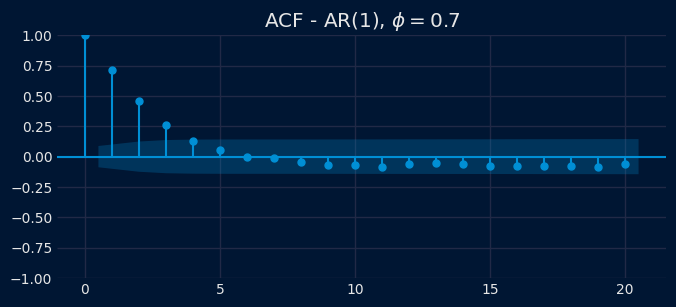

In [3]:
# Plot the ACF (statsmodels, fastest configuration)
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
plot_acf(y_ar1, lags=20, alpha=0.05, fft=True, ax=ax)
ax.set_title('ACF - AR(1), $\\phi = 0.7$')
plt.show()

## Partial autocorrelation function (PACF)

The PACF at lag *k* measures the linear correlation between $y_t$ and $y_{t-k}$ **after removing the linear effect of all intermediate lags** $y_{t-1}, \dots, y_{t-k+1}$. It isolates the *direct* contribution of lag *k*, which is exactly what is needed to choose the order of an autoregressive model.

Reading rule:

- **PACF cuts off after lag *p*** &rarr; suggests an AR(p) component (lags 1 to *p* are the relevant ones).
- **PACF decays slowly** &rarr; suggests an MA or mixed process.

Below, an AR(2) series is simulated. The expected pattern is two significant PACF coefficients at lags 1 and 2, and everything else inside the white-noise band.

In [4]:
# Simulate an AR(2) process: y_t = 0.6 * y_{t-1} - 0.3 * y_{t-2} + eps_t
# ==============================================================================
phi1, phi2 = 0.6, -0.3
y_ar2 = np.zeros(n)
for t in range(2, n):
    y_ar2[t] = phi1 * y_ar2[t - 1] + phi2 * y_ar2[t - 2] + rng.standard_normal()

# PACF with 95% white-noise confidence intervals
pacf_vals, _ = pacf(y_ar2, nlags=20, alpha=0.05)
print('PACF, lags 0-5:', pacf_vals[:6].round(3))

PACF, lags 0-5: [ 1.     0.482 -0.348  0.084 -0.031 -0.008]


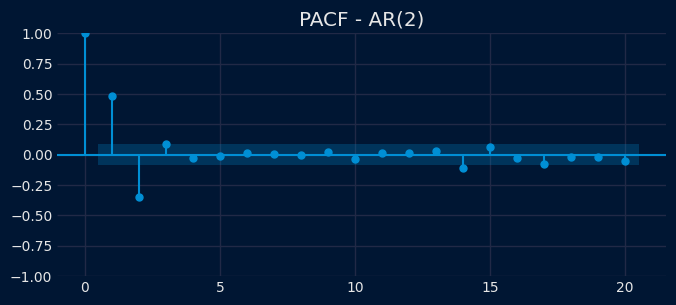

In [5]:
# Plot the PACF (statsmodels, fastest configuration)
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
plot_pacf(y_ar2, lags=20, alpha=0.05, method='burg', ax=ax)
ax.set_title('PACF - AR(2)')
plt.show()

## ACF and PACF of an MA(1) process

In the AR examples above, the PACF was the plot that cut off sharply. A moving-average process shows the opposite pattern: here the ACF cuts off and the PACF decays gradually. Seeing this mirror image helps confirm how the reading rules work.

To illustrate, the cell below simulates an MA(1) series, $y_t = \varepsilon_t + 0.8\,\varepsilon_{t-1}$. Expect a single significant spike in the ACF at lag 1, and a PACF that decays slowly, often oscillating between positive and negative values.

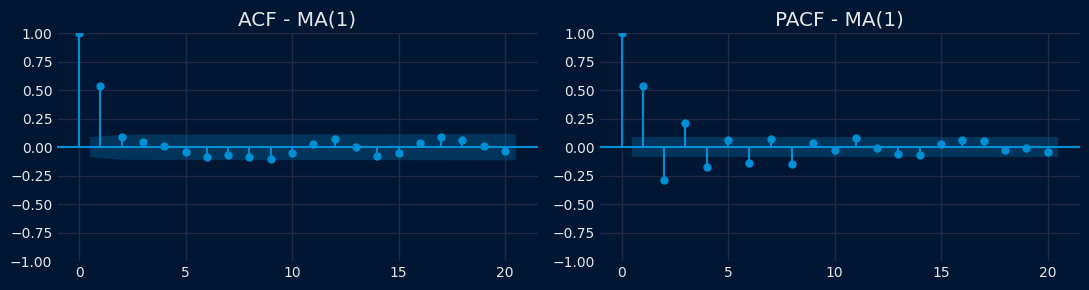

In [6]:
# Simulate an MA(1) process: y_t = eps_t + 0.8 * eps_{t-1}
# ==============================================================================
theta = 0.8
eps = rng.standard_normal(n + 1)
y_ma1 = eps[1:] + theta * eps[:-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(y_ma1, lags=20, alpha=0.05, fft=True, ax=axes[0])
plot_pacf(y_ma1, lags=20, alpha=0.05, method='burg', ax=axes[1])
axes[0].set_title('ACF - MA(1)')
axes[1].set_title('PACF - MA(1)')
plt.tight_layout()
plt.show()

## Detecting trend and seasonality on a real series

Real series rarely look like a clean AR or MA process: trend and seasonality typically dominate the ACF and PACF, and reading them is one of the quickest ways to detect those components. As an example, we use the `h2o` dataset (monthly Australian expenditure on corticosteroid drugs, 1991&ndash;2008) included in `skforecast.datasets`.

╭────────────────────────────────────── h2o ───────────────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health    │
│ system had between 1991 and 2008.                                                │
│                                                                                  │
│ Source:                                                                          │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice(3rd        │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,https://github.com/robjhyndman │
│ /fpp3package, http://OTexts.com/fpp3.                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/h2o.csv                                                       │
│                                                                                  │
│ Shape: 204 rows x 1 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

date
1991-07-01    0.429795
1991-08-01    0.400906
1991-09-01    0.432159
1991-10-01    0.492543
1991-11-01    0.502369
Freq: MS, Name: y, dtype: float64

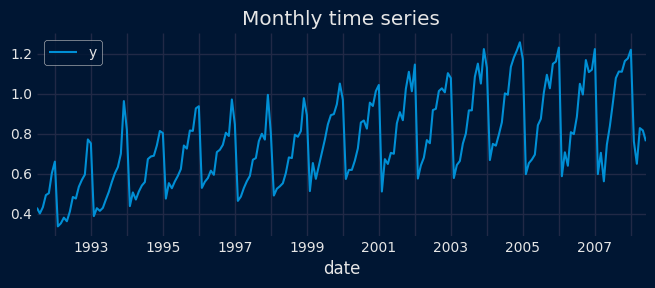

In [7]:
# Load monthly time series
# ==============================================================================
data = fetch_dataset(name='h2o', verbose=True)
y = data['x'].rename('y')
y.index.name = 'date'
display(y.head())

# Plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 2.5))
y.plot(ax=ax, label='y')
ax.set_title('Monthly time series')
ax.legend();

### Seasonal decomposition

Seasonal decomposition splits a time series into three components: **trend** (the long-term direction), **seasonal** (the repeating cycle, e.g. yearly), and **residual** (what is left after removing the other two). It is a useful first step in any analysis because it makes the underlying structure explicit: you can see whether the series is trending, how strong the seasonality is, and whether the residuals look like random noise or still hide unexplained patterns.

There are two common decomposition models:

- **Additive** ($y_t = \text{trend}_t + \text{seasonal}_t + \text{residual}_t$): the seasonal effect is a roughly constant amount, independent of the series level.
- **Multiplicative** ($y_t = \text{trend}_t \times \text{seasonal}_t \times \text{residual}_t$): the seasonal effect is proportional to the series level (a percentage), so the swings grow as the series rises and shrink as it falls.

See the [statsmodels `seasonal_decompose` documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) for details.

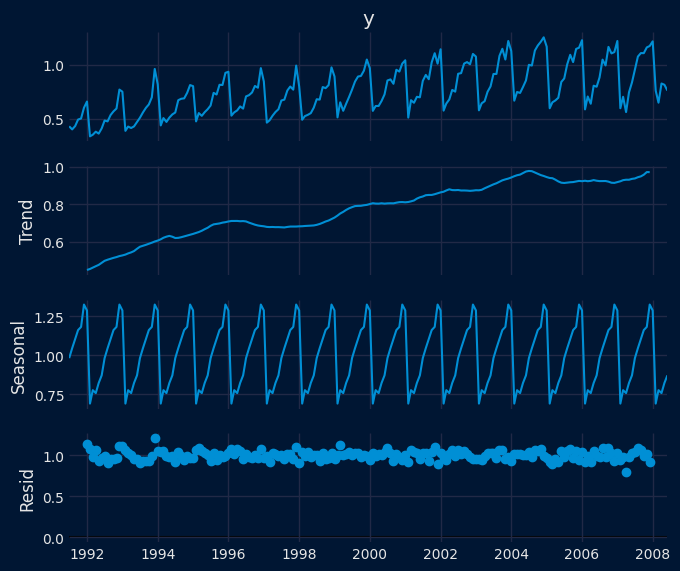

In [8]:
# Decompose the time series into trend, seasonal and residual components
# ==============================================================================
result = seasonal_decompose(y, model='multiplicative', period=12)

fig = result.plot()
fig.set_size_inches(7, 6)
plt.show()

Because the seasonal fluctuations of this series grow with its level (see the trend and seasonal decomposition above), a **multiplicative** model is used. In this decomposition the seasonal and residual components are expressed as factors around 1.0 rather than absolute deviations: a seasonal value of 1.3 means the series is 30% above trend that month, and 0.8 means 20% below. The result is a stable seasonal pattern and residuals with roughly constant variance across the whole period.

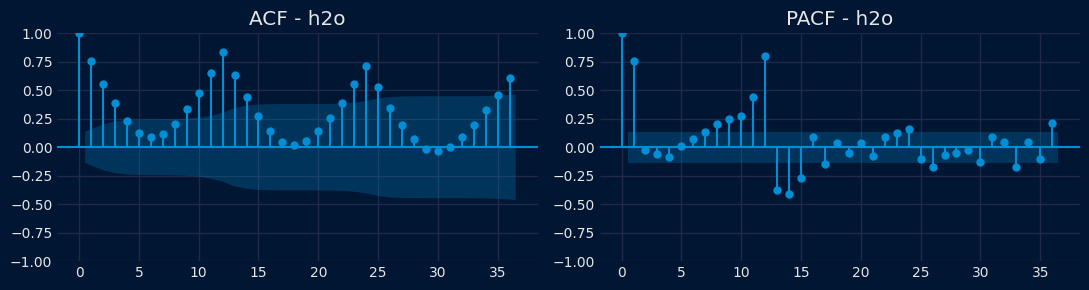

In [9]:
# ACF / PACF view
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(y, lags=36, alpha=0.05, fft=True, ax=axes[0])
plot_pacf(y, lags=36, alpha=0.05, method='burg', ax=axes[1])
axes[0].set_title('ACF - h2o')
axes[1].set_title('PACF - h2o')
plt.tight_layout()
plt.show()

Two patterns are visible:

- The **ACF decays slowly and shows clear peaks at lags 12, 24 and 36**, the unmistakable signature of an annual seasonal cycle on monthly data.
- The **PACF has a strong spike at lag 1** and additional smaller spikes around lag 12, suggesting that the most informative *direct* dependencies are the previous month and the same month one year ago.

The slow, almost linear decay of the ACF is driven by the upward trend.

After differencing, the slow decay disappears and the seasonal structure becomes much clearer: the residual spikes at lags 12 and 24 confirm the annual cycle, while the short-term dependence collapses to the first one or two lags. This is the structure the lag selection should target.

### Ranking lags with `calculate_lag_autocorrelation`

When a tabular view is more convenient (for example, to feed an automatic lag selection routine), `calculate_lag_autocorrelation` returns a DataFrame with ACF and PACF values for all lags, sorted by absolute partial autocorrelation. This makes it easy to keep the *N* lags that contribute most to the conditional variance.

In [10]:
# Top lags ranked by |PACF|
# ==============================================================================
lag_table = calculate_lag_autocorrelation(
                data    = y,
                n_lags  = 24,
                sort_by = 'partial_autocorrelation_abs'
            )
lag_table.head(10)

,lag,partial_autocorrelation_abs,partial_autocorrelation,autocorrelation_abs,autocorrelation
0,1,0.754819,0.754819,0.754819,0.754819
1,13,0.581951,-0.581951,0.630189,0.630189
2,12,0.564231,0.564231,0.838637,0.838637
3,11,0.357985,0.357985,0.650629,0.650629
4,10,0.229213,0.229213,0.479473,0.479473
5,14,0.221144,-0.221144,0.437928,0.437928
6,9,0.214591,0.214591,0.334505,0.334505
7,8,0.168774,0.168774,0.202611,0.202611
8,7,0.126981,0.126981,0.115865,0.115865
9,16,0.111945,0.111945,0.139812,0.139812


In [11]:
# Keep lags whose |PACF| exceeds the asymptotic 95% white-noise band (1.96 / sqrt(n))
# ==============================================================================
threshold = 1.96 / np.sqrt(len(y))
selected_lags = (
    lag_table
    .loc[lag_table['partial_autocorrelation_abs'] > threshold, 'lag']
    .astype(int)
    .sort_values()
    .tolist()
)
print(f'Selected lags: {selected_lags}')

Selected lags: [1, 8, 9, 10, 11, 12, 13, 14]


### Using the selected lags in a Forecaster

The selected lags can be passed directly to any skforecast forecaster. The example below trains a `ForecasterRecursive` with a gradient boosting estimator and the lags identified from the PACF.

In [12]:
# Build a forecaster with the selected lags
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator = HistGradientBoostingRegressor(random_state=963),
                 lags      = selected_lags,
             )

forecaster.fit(y=y)
forecaster.predict(steps=12).round(2)

2008-07-01    0.90
2008-08-01    1.05
2008-09-01    1.13
2008-10-01    1.18
2008-11-01    1.14
2008-12-01    1.18
2009-01-01    1.19
2009-02-01    0.82
2009-03-01    0.70
2009-04-01    0.81
2009-05-01    0.82
2009-06-01    0.82
Freq: MS, Name: pred, dtype: float64

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161; Tip</b>
</p>

The lags identified from ACF/PACF analysis are an informed <i>starting point</i>, not a final answer. Once a candidate set is chosen, the <a href="../user_guides/hyperparameter-tuning-and-lags-selection.html">Hyperparameter tuning and lags selection</a> guide shows how to refine it via cross-validation, and the <a href="../user_guides/feature-selection.html">Feature selection</a> guide explains how to prune redundant predictors.

</div>

## Speeding up the computation on long series

On very long series, computing the ACF and PACF over the whole history is rarely necessary: the most recent observations usually carry the dynamics relevant for forecasting. The `last_n_samples` argument of `calculate_lag_autocorrelation` restricts the calculation to the most recent observations, which speeds it up and emphasises the current behaviour of the series.

In [13]:
# Restrict the computation to the most recent observations
# ==============================================================================
lag_table_recent = calculate_lag_autocorrelation(
                       data           = y,
                       n_lags         = 24,
                       last_n_samples = 120,  # use only the last 120 observations
                       sort_by        = 'partial_autocorrelation_abs'
                   )
lag_table_recent.head(10)

,lag,partial_autocorrelation_abs,partial_autocorrelation,autocorrelation_abs,autocorrelation
0,12,0.657180,0.657180,0.825784,0.825784
1,1,0.614762,0.614762,0.614762,0.614762
2,13,0.389924,-0.389924,0.528852,0.528852
3,11,0.286151,0.286151,0.521157,0.521157
4,4,0.229297,-0.229297,0.212387,-0.212387
5,10,0.217552,0.217552,0.279033,0.279033
6,3,0.214482,-0.214482,0.046837,0.046837
7,16,0.184205,0.184205,0.216746,-0.216746
8,14,0.183697,-0.183697,0.258777,0.258777
9,5,0.169333,-0.169333,0.379954,-0.379954
